<a href="https://colab.research.google.com/github/raphaelassoun23/Projet-Python/blob/main/notebooks/MonteCarloCrypto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import sys
from pathlib import Path

SRC_PATH = Path("..") / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from fetch import fetch_dataset

In [29]:
from config import TICKERS, ROLLING_WINDOW_DAYS, EVENT_DATE, EVENT_WINDOW_DAYS, EVENT_ROLLING_DAYS
from fetch import fetch_dataset
from process import build_final_dataset
from visualize import print_correlations, plot_btc_sp500, plot_btc_nasdaq, plot_sp500_nasdaq, plot_event_window, plot_btc_and_us10y, plot_rolling_corr, plot_scatter_returns, plot_event_study_rate_shocks, plot_btc_vs_slope


ImportError: cannot import name 'plot_btc_and_us10y' from 'visualize' (c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\visualize.py)

Les valeurs manquantes présentes dans le dataset proviennent uniquement des transformations réalisées (retours, volatilités, moyennes mobiles). Ces NaN correspondent aux premières observations où les fenêtres de calcul ne sont pas encore complètes.
Ils ne représentent donc pas de véritables trous dans les données.
Leur suppression est justifiée, car elle ne retire qu’un très faible nombre d’observations et évite d’introduire un biais par une imputation artificielle
(par la moyenne,par la médiane ou par régression)

c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\fetch.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max").reset_index()
[*********************100%***********************]  1 of 1 completed
c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\fetch.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max").reset_index()
[*********************100%***********************]  1 of 1 completed
c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\fetch.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="max").reset_index()
[*********************100%***********************]  1 of 1 completed
c:\Users\dangt\OneDrive\ENSAE\Projet-Python\notebooks\..\src\fetch.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticke

                     BTC_return_daily  SP500_return_daily  NASDAQ_return_daily
BTC_return_daily             1.000000            0.294883             0.311543
SP500_return_daily           0.294883            1.000000             0.950950
NASDAQ_return_daily          0.311543            0.950950             1.000000

                     ETH_return_daily  SP500_return_daily  NASDAQ_return_daily
ETH_return_daily             1.000000            0.321687             0.335959
SP500_return_daily           0.321687            1.000000             0.950950
NASDAQ_return_daily          0.335959            0.950950             1.000000

                  ETH_return_daily  BTC_return_daily
ETH_return_daily          1.000000          0.812474
BTC_return_daily          0.812474          1.000000



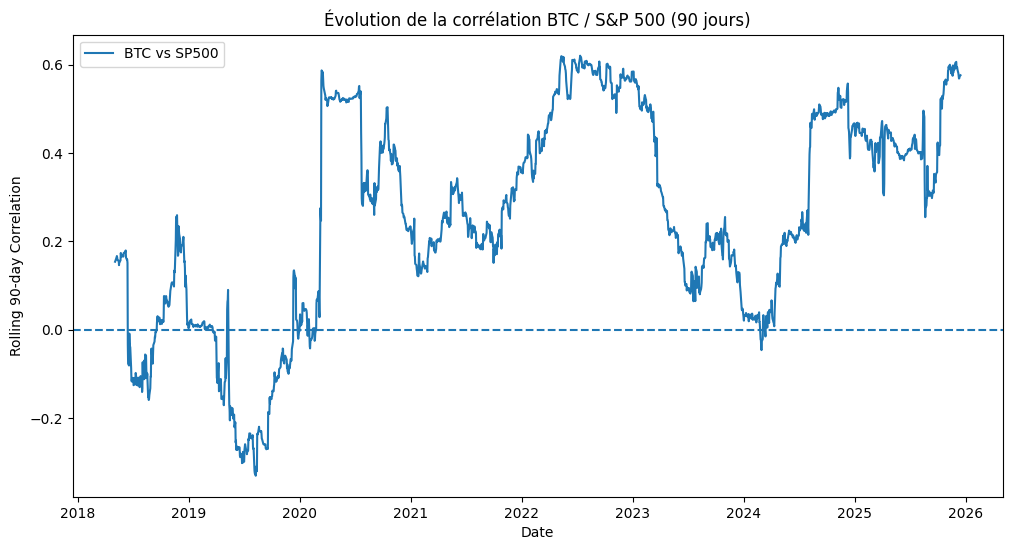

In [ ]:
df = fetch_dataset(TICKERS)
df_final = build_final_dataset(df)

print_correlations(df_final)
plot_btc_sp500(df_final)

Les premières observations sur les rendements journaliers montrent que le Bitcoin présente une corrélation faible à modérée avec le S&P 500 (≈0,29) et le NASDAQ (≈0,31). En comparaison, le S&P 500 et le NASDAQ sont fortement corrélés entre eux (≈0,95), comme attendu.
Ces résultats suggèrent qu’au niveau global, le Bitcoin ne suit pas étroitement les marchés financiers traditionnels et pourrait évoluer de manière relativement indépendante. Il s’agit pour l’instant d’une analyse exploratoire, qui devra être complétée par une étude dynamique dans le temps et des tests plus approfondis pour confirmer ces tendances.

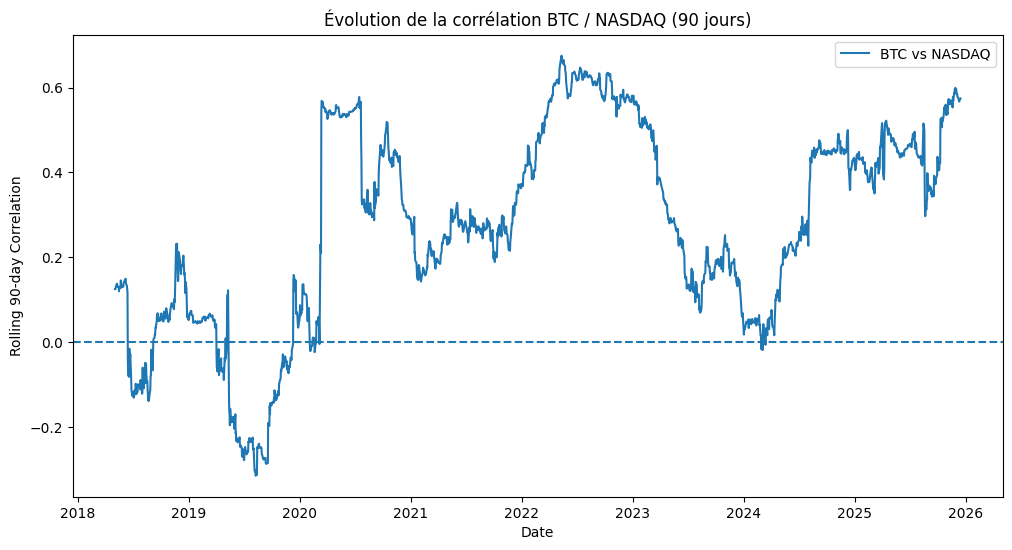

In [ ]:
plot_btc_nasdaq(df_final)

Le graphique met en évidence une corrélation très instable dans le temps entre Bitcoin et les indices boursiers traditionnels (Nasdaq et S&P 500). Contrairement aux actifs financiers classiques, dont la corrélation reste généralement plus stable, Bitcoin présente une structure de dépendance très volatile : certaines périodes montrent une corrélation nettement positive, tandis que d’autres phases se caractérisent par une décorrélation quasi totale.
Cette dynamique confirme que Bitcoin ne réagit pas systématiquement aux mêmes facteurs macroéconomiques que les actions. Les phases de corrélation élevée semblent principalement associées à des épisodes de tension macro ou financière, où les actifs risqués évoluent de manière plus synchronisée. À l’inverse, lorsque les conditions se normalisent, Bitcoin retrouve un comportement plus autonome.
Ces résultats suggèrent que Bitcoin ne pourrait pas être considéré comme un actif structurellement aligné avec les marchés actions : son potentiel de diversification dépend fortement de la période étudiée.

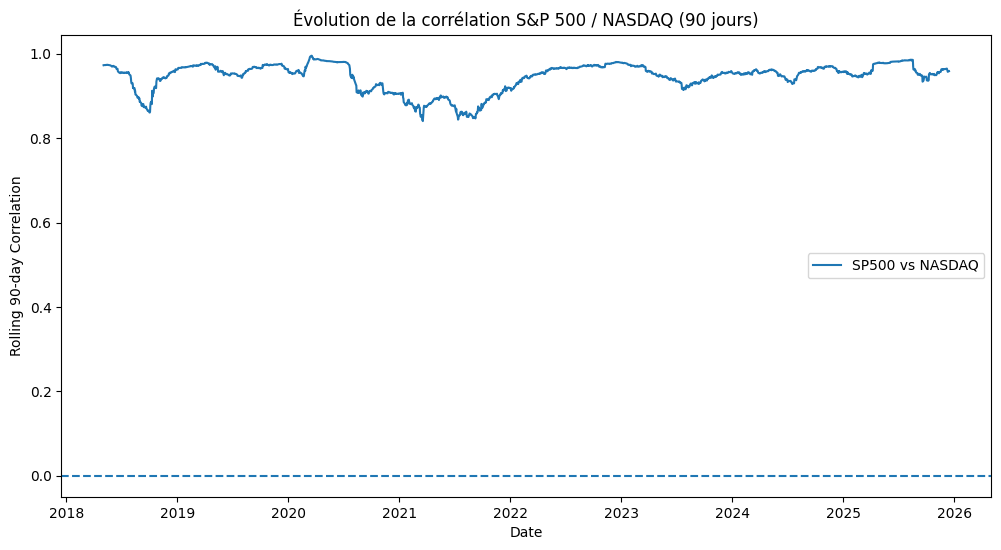

In [ ]:
plot_sp500_nasdaq(df_final)

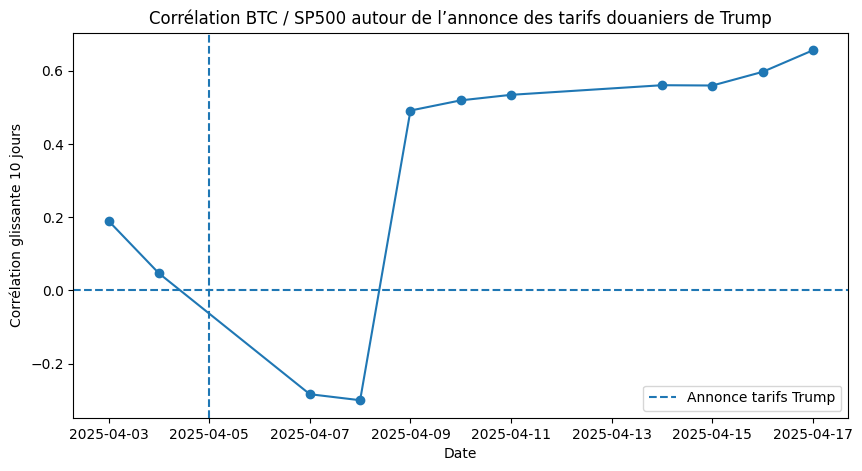

In [ ]:
plot_event_window(
    df_final,
    EVENT_DATE,
    window_days=EVENT_WINDOW_DAYS,
    rolling_days=EVENT_ROLLING_DAYS
)

Pendant l’annonce des tarifs douaniers, la corrélation BTC / SP500 augmente, car un choc macroéconomique majeur fait réagir simultanément les investisseurs sur plusieurs actifs. Cette corrélation élevée est temporaire, et Bitcoin reprend ensuite son comportement relativement indépendant comme on a pu le voir avec les graphes précédents.

In [ ]:
plot_btc_and_us10y(df_final)
plot_rolling_corr(df_final, window=60)
plot_scatter_returns(df_final)
plot_event_study_rate_shocks(df_final, shock_quantile=0.99, pre=5, post=10)